# 1- cleaning data 

# 1-1 specific gravity dataset

Threshold = 6.353
Number of Outliers = 262

Top Suspected Outliers

      Pressure (psia)  Hydrate Temperature (K)   Residual
2916      2000.000000               321.470000  27.538410
2926      2000.000000               320.370000  26.438410
2906      2000.000000               319.550000  25.618410
2915      1796.000000               316.280000  22.639074
2925      1820.000000               315.440000  21.797812
2905      1814.000000               314.480000  20.834454
2946      2000.000000               313.480000  19.548410
2956      2000.000000               313.120000  19.188410
2914      1591.000000               311.080000  18.682103
2966      2000.000000               312.490000  18.558410
2976      2000.000000               312.400000  18.468410
2924      1639.000000               310.510000  17.844295
2904      1628.000000               309.420000  16.829531
2936      2000.000000               310.400000  16.468410
2986      2000.000000               310.400000  16.468410
3003

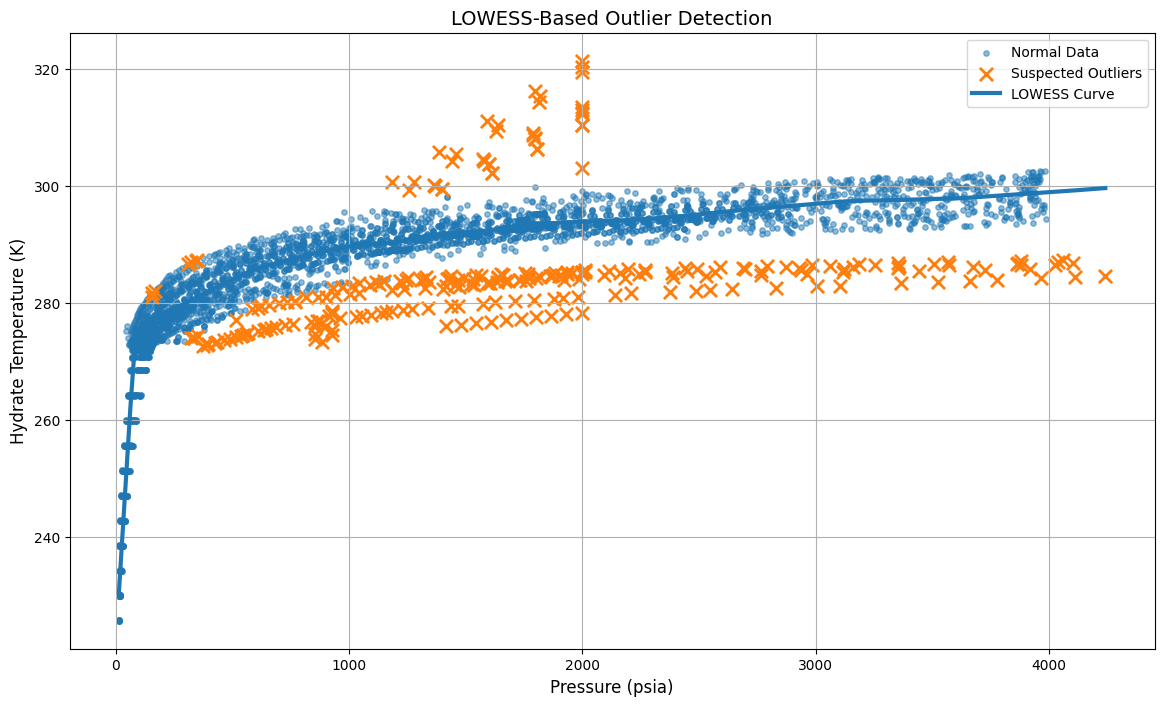


Clean dataset saved:
sp_gr_dataset_clean.csv

Outlier dataset saved:
Candidate_Outliers.xlsx


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.nonparametric.smoothers_lowess import lowess

# ==========================================================
# LOAD DATA
# ==========================================================

df = pd.read_csv("sp_gr dataset.csv")

# ==========================================================
# VARIABLES
# ==========================================================

P = df["Pressure (psia)"].values
T = df["Hydrate Temperature (K)"].values

# ==========================================================
# LOWESS FIT
# ==========================================================

lowess_fit = lowess(
    T,
    P,
    frac=0.08,
    return_sorted=True
)

P_fit = lowess_fit[:, 0]
T_fit = lowess_fit[:, 1]

# ==========================================================
# INTERPOLATE LOWESS TO ALL DATA POINTS
# ==========================================================

T_pred = np.interp(
    P,
    P_fit,
    T_fit
)

# ==========================================================
# RESIDUALS
# ==========================================================

residuals = np.abs(
    T - T_pred
)

# ==========================================================
# OUTLIER THRESHOLD
# ==========================================================

threshold = (
    residuals.mean()
    + 1.2 * residuals.std()
)

# ==========================================================
# STORE RESULTS
# ==========================================================

df["LOWESS_Predicted"] = T_pred
df["Residual"] = residuals

# ==========================================================
# OUTLIER LOGIC
# Ignore low-pressure hydrate curve region
# ==========================================================

df["Outlier"] = (
    (df["Residual"] > threshold)
    &
    (df["Pressure (psia)"] > 150)
    &
    (df["Hydrate Temperature (K)"] > 270)
)

# ==========================================================
# SUMMARY
# ==========================================================

print(f"Threshold = {threshold:.3f}")
print(f"Number of Outliers = {df['Outlier'].sum()}")

# ==========================================================
# OUTLIER DATAFRAME
# ==========================================================

candidate_outliers = (
    df[df["Outlier"]]
    .sort_values(
        "Residual",
        ascending=False
    )
)

print("\nTop Suspected Outliers\n")
print(
    candidate_outliers[
        [
            "Pressure (psia)",
            "Hydrate Temperature (K)",
            "Residual"
        ]
    ].head(50)
)

# ==========================================================
# SAVE OUTLIERS
# ==========================================================

candidate_outliers.to_excel(
    "Candidate_Outliers.xlsx",
    index=False
)

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(14, 8))

normal = df[df["Outlier"] == False]
outliers = df[df["Outlier"] == True]

plt.scatter(
    normal["Pressure (psia)"],
    normal["Hydrate Temperature (K)"],
    s=15,
    alpha=0.5,
    label="Normal Data"
)

plt.scatter(
    outliers["Pressure (psia)"],
    outliers["Hydrate Temperature (K)"],
    s=90,
    marker="x",
    linewidths=2,
    label="Suspected Outliers"
)

plt.plot(
    P_fit,
    T_fit,
    linewidth=3,
    label="LOWESS Curve"
)

plt.xlabel("Pressure (psia)", fontsize=12)
plt.ylabel("Hydrate Temperature (K)", fontsize=12)
plt.title("LOWESS-Based Outlier Detection", fontsize=14)

plt.legend()
plt.grid(True)

plt.show()

# ==========================================================
# SAVE CLEAN DATASET
# ==========================================================

clean_df = df[df["Outlier"] == False]

clean_df.to_csv(
    "sp_gr_dataset_clean.csv",
    index=False
)

print("\nClean dataset saved:")
print("sp_gr_dataset_clean.csv")

print("\nOutlier dataset saved:")
print("Candidate_Outliers.xlsx")

Threshold = 5.911
Number of Outliers = 179

Top Suspected Outliers

      Pressure (psia)  Hydrate Temperature (K)   Residual
1910      4242.692966               284.595144  15.478207
1909      4113.618789               284.412728  15.057938
1908      3968.403825               284.230313  14.647457
1907      3778.356485               283.895885  14.408086
1903      3105.578361               282.983808  14.407163
1906      3663.793668               283.743872  14.270495
1902      3007.619648               282.831795  14.209299
1904      3366.960997               283.379041  14.196279
1905      3525.555155               283.561457  14.178478
1901      2829.186772               282.649380  13.768115
1900      2641.279686               282.466965  13.367250
1899      2548.039803               282.284549  13.206445
1892      1877.115568               280.703617  13.150492
1898      2489.284759               282.102134  13.137518
1893      1916.581661               280.886032  13.105673
1894

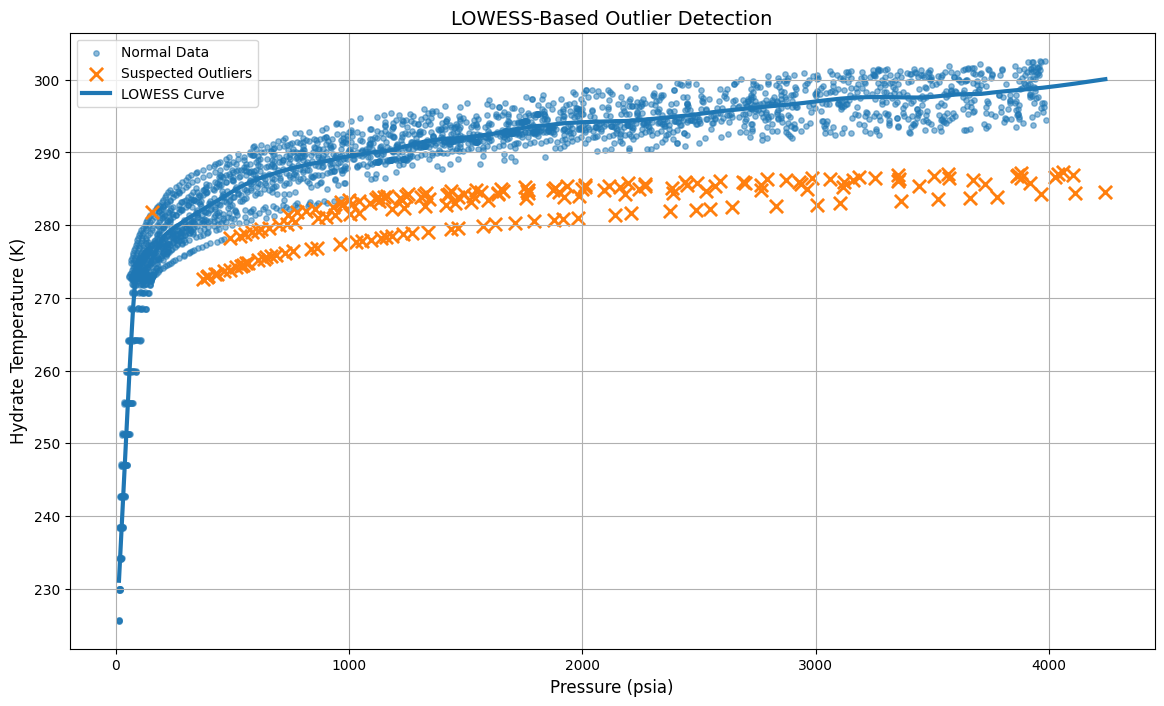


Clean dataset saved:
sp_gr_dataset_clean.csv

Outlier dataset saved:
Candidate_Outliers.xlsx


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.nonparametric.smoothers_lowess import lowess

# ==========================================================
# LOAD DATA
# ==========================================================

df = pd.read_csv("new_csv1.csv", sep=";")

# ==========================================================
# VARIABLES
# ==========================================================

P = df["Pressure (psia)"].values
T = df["Hydrate Temperature (K)"].values

# ==========================================================
# LOWESS FIT
# ==========================================================

lowess_fit = lowess(
    T,
    P,
    frac=0.08,
    return_sorted=True
)

P_fit = lowess_fit[:, 0]
T_fit = lowess_fit[:, 1]

# ==========================================================
# INTERPOLATE LOWESS TO ALL DATA POINTS
# ==========================================================

T_pred = np.interp(
    P,
    P_fit,
    T_fit
)

# ==========================================================
# RESIDUALS
# ==========================================================

residuals = np.abs(
    T - T_pred
)

# ==========================================================
# OUTLIER THRESHOLD
# ==========================================================

threshold = (
    residuals.mean()
    + 1.2 * residuals.std()
)

# ==========================================================
# STORE RESULTS
# ==========================================================

df["LOWESS_Predicted"] = T_pred
df["Residual"] = residuals

# ==========================================================
# OUTLIER LOGIC
# Ignore low-pressure hydrate curve region
# ==========================================================

df["Outlier"] = (
    (df["Residual"] > threshold)
    &
    (df["Pressure (psia)"] > 150)
    &
    (df["Hydrate Temperature (K)"] > 270)
)

# ==========================================================
# SUMMARY
# ==========================================================

print(f"Threshold = {threshold:.3f}")
print(f"Number of Outliers = {df['Outlier'].sum()}")

# ==========================================================
# OUTLIER DATAFRAME
# ==========================================================

candidate_outliers = (
    df[df["Outlier"]]
    .sort_values(
        "Residual",
        ascending=False
    )
)

print("\nTop Suspected Outliers\n")
print(
    candidate_outliers[
        [
            "Pressure (psia)",
            "Hydrate Temperature (K)",
            "Residual"
        ]
    ].head(50)
)

# ==========================================================
# SAVE OUTLIERS
# ==========================================================

candidate_outliers.to_excel(
    "Candidate_Outliers2.xlsx",
    index=False
)

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(14, 8))

normal = df[df["Outlier"] == False]
outliers = df[df["Outlier"] == True]

plt.scatter(
    normal["Pressure (psia)"],
    normal["Hydrate Temperature (K)"],
    s=15,
    alpha=0.5,
    label="Normal Data"
)

plt.scatter(
    outliers["Pressure (psia)"],
    outliers["Hydrate Temperature (K)"],
    s=90,
    marker="x",
    linewidths=2,
    label="Suspected Outliers"
)

plt.plot(
    P_fit,
    T_fit,
    linewidth=3,
    label="LOWESS Curve"
)

plt.xlabel("Pressure (psia)", fontsize=12)
plt.ylabel("Hydrate Temperature (K)", fontsize=12)
plt.title("LOWESS-Based Outlier Detection", fontsize=14)

plt.legend()
plt.grid(True)

plt.show()

# ==========================================================
# SAVE CLEAN DATASET
# ==========================================================

clean_df = df[df["Outlier"] == False]

clean_df.to_csv(
    "new_csv1_dataset_clean.csv",
    index=False
)

print("\nClean dataset saved:")
print("sp_gr_dataset_clean.csv")

print("\nOutlier dataset saved:")
print("Candidate_Outliers.xlsx")

# 1-2 composition dataset

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11404\2655468725.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


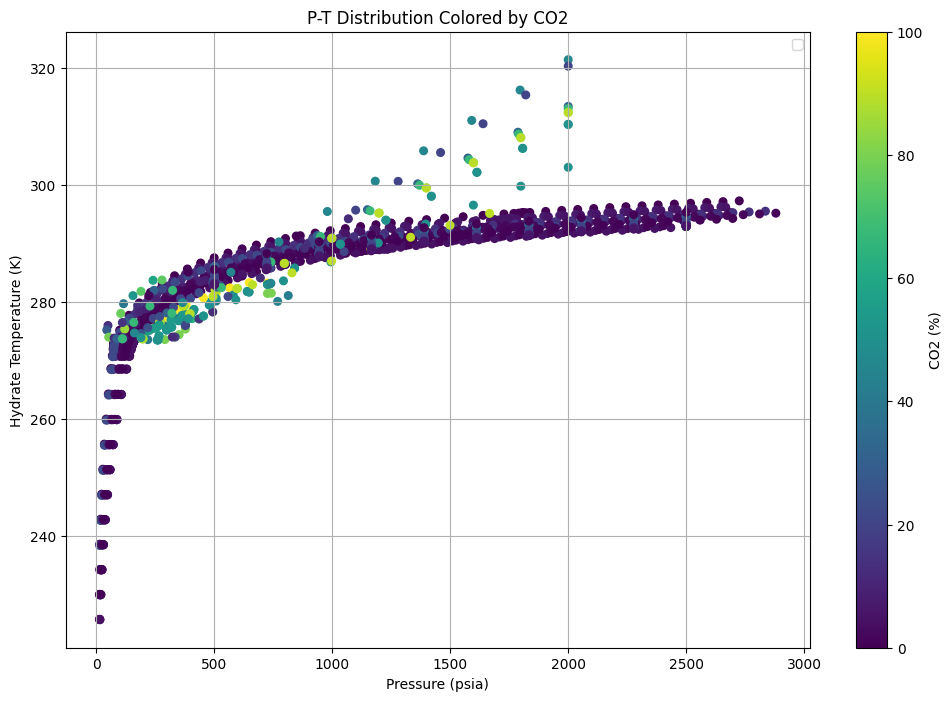

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("composition_unclean.xlsx")

plt.figure(figsize=(12,8))

sc = plt.scatter(
    df["Pressure (psia)"],
    df["Hydrate Temperature (K)"],
    c=df["Carbon Dioxide"],
    cmap="viridis",
    s=30
)



plt.colorbar(sc, label="CO2 (%)")

plt.xlabel("Pressure (psia)")
plt.ylabel("Hydrate Temperature (K)")
plt.title("P-T Distribution Colored by CO2")

plt.legend()
plt.grid(True)

plt.show()

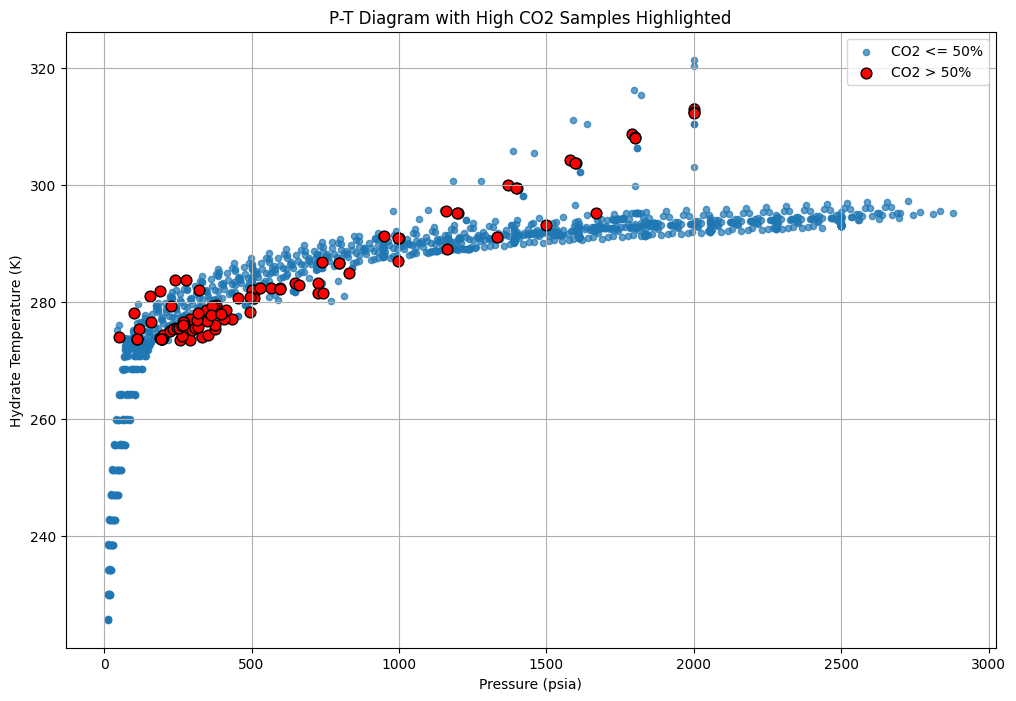

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_excel("composition_unclean.xlsx")

# ==========================================
# SPLIT DATA
# ==========================================

normal = df[df["Carbon Dioxide"] <= 50]

outliers = df[df["Carbon Dioxide"] > 50]

# ==========================================
# P-T PLOT
# ==========================================

plt.figure(figsize=(12,8))

plt.scatter(
    normal["Pressure (psia)"],
    normal["Hydrate Temperature (K)"],
    s=20,
    alpha=0.7,
    label="CO2 <= 50%"
)

plt.scatter(
    outliers["Pressure (psia)"],
    outliers["Hydrate Temperature (K)"],
    s=60,
    c="red",
    edgecolors="black",
    label="CO2 > 50%"
)

plt.xlabel("Pressure (psia)")
plt.ylabel("Hydrate Temperature (K)")
plt.title("P-T Diagram with High CO2 Samples Highlighted")

plt.grid(True)
plt.legend()

plt.show()

In [54]:
import pandas as pd

df = pd.read_excel("composition_unclean.xlsx")

outliers = df[
    (df["Pressure (psia)"] >= 1000) &
    (df["Pressure (psia)"] <= 2200) &
    (df["Hydrate Temperature (K)"] > 297)
]

clean_df = df.drop(outliers.index)

print("Removed =", len(outliers))
print("Remaining =", len(clean_df))

clean_df.to_excel(
    "composition_dataset_clean.xlsx",
    index=False
)

outliers.to_excel(
    "composition_upper_branch_outliers.xlsx",
    index=False
)

Removed = 36
Remaining = 1608


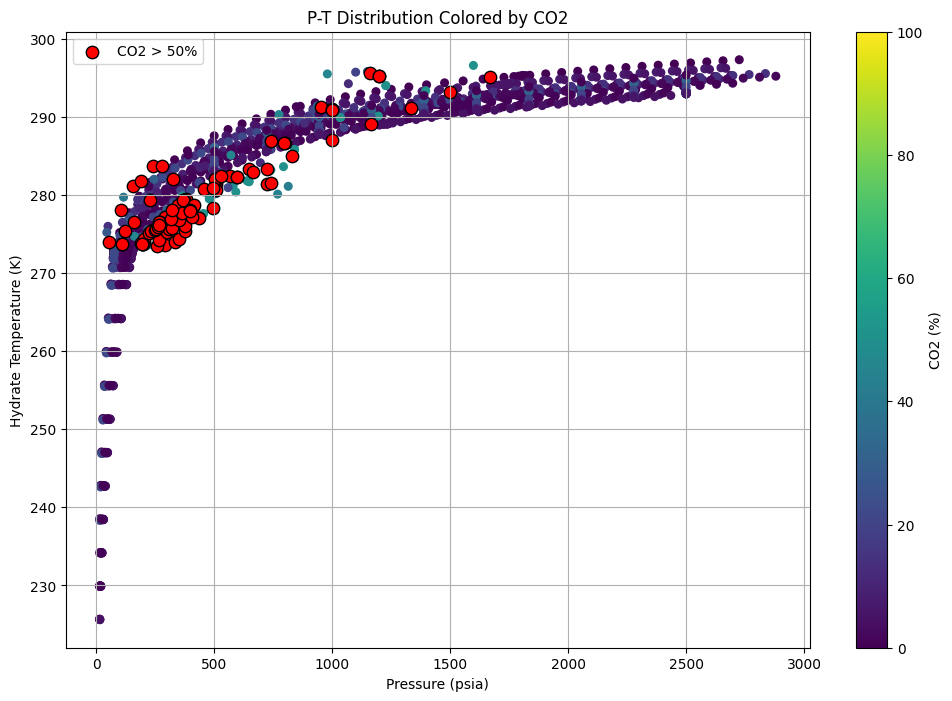

In [57]:
plt.figure(figsize=(12,8))
df = pd.read_excel("composition_dataset_clean.xlsx")

sc = plt.scatter(
    df["Pressure (psia)"],
    df["Hydrate Temperature (K)"],
    c=df["Carbon Dioxide"],
    cmap="viridis",
    s=30
)

high_co2 = df[df["Carbon Dioxide"] > 50]

plt.scatter(
    high_co2["Pressure (psia)"],
    high_co2["Hydrate Temperature (K)"],
    c="red",
    s=80,
    edgecolors="black",
    label="CO2 > 50%"
)

plt.colorbar(sc, label="CO2 (%)")

plt.xlabel("Pressure (psia)")
plt.ylabel("Hydrate Temperature (K)")
plt.title("P-T Distribution Colored by CO2")

plt.legend()
plt.grid(True)

plt.show()